In [3]:
# Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Carga de datos

df_model = pd.read_csv(
    "../data/Silver/grupo_exito_features.csv",
    parse_dates=["fecha"]
)

df_model = (
    df_model
    .sort_values("fecha")
    .reset_index(drop=True)
)

print("Dimensiones:", df_model.shape)

df_model.head()

Dimensiones: (20, 31)


,año,fecha,ingresos,utilidad_bruta,ebitda_recurrente,resultado_neto,t,ingresos_lag1,utilidad_bruta_lag1,ebitda_recurrente_lag1,...,ebitda_recurrente_rolling_std_4,resultado_neto_rolling_std_4,ingresos_yoy_pct,utilidad_bruta_yoy_pct,ebitda_recurrente_yoy_pct,resultado_neto_yoy_diff,T_1,T_2,T_3,T_4
0,2021,2021-03-31,3819172,1016535,306694,84957,5,4345013.0,1142061.0,460429.0,...,97268.104969,60066.709288,-5.756026,1.539573,16.688227,62970.0,1,0,0,0
1,2021,2021-06-30,3696687,959633,306557,50744,6,3819172.0,1016535.0,306694.0,...,91268.194155,55671.603261,0.223156,5.237341,2.478413,37957.0,0,1,0,0
2,2021,2021-09-30,4163857,1061678,353514,126315,7,3696687.0,959633.0,306557.0,...,90533.939461,43865.569401,14.080181,17.719496,41.713402,74501.0,0,0,1,0
3,2021,2021-12-31,5242669,1395683,568638,212665,8,4163857.0,1061678.0,353514.0,...,72536.744052,42016.166595,20.659455,22.207395,23.501778,68381.0,0,0,0,1
4,2022,2022-03-31,4601967,1174498,355163,64539,9,5242669.0,1395683.0,568638.0,...,125158.744564,69866.572586,20.496458,15.539357,15.803700,-20418.0,1,0,0,0


In [5]:
# Variables objetivo

variables_objetivo = [
    "ingresos",
    "utilidad_bruta",
    "ebitda_recurrente",
    "resultado_neto"
]

In [7]:
# División temporal Train/Test
# El periodo temporal de entrenamiento es desde 2021 a 2024
# El periodo temporal de prueba es 2025

n_test = 4

df_train = df_model.iloc[:-n_test].copy()
df_test = df_model.iloc[-n_test:].copy()

print("Observaciones entrenamiento:", len(df_train))
print("Observaciones prueba:", len(df_test))

print("\nPeríodo entrenamiento:")
print(
    df_train["fecha"].min(),
    "→",
    df_train["fecha"].max()
)

print("\nPeríodo prueba:")
print(
    df_test["fecha"].min(),
    "→",
    df_test["fecha"].max()
)

Observaciones entrenamiento: 16
Observaciones prueba: 4

Período entrenamiento:
2021-03-31 00:00:00 → 2024-12-31 00:00:00

Período prueba:
2025-03-31 00:00:00 → 2025-12-31 00:00:00


In [8]:
df_test[
    [
        "fecha",
        "ingresos",
        "ingresos_lag4",
        "utilidad_bruta",
        "utilidad_bruta_lag4",
        "ebitda_recurrente",
        "ebitda_recurrente_lag4",
        "resultado_neto",
        "resultado_neto_lag4"
    ]
]

,fecha,ingresos,ingresos_lag4,utilidad_bruta,utilidad_bruta_lag4,ebitda_recurrente,ebitda_recurrente_lag4,resultado_neto,resultado_neto_lag4
16,2025-03-31,5404642,5275139.0,1382773,1321953.0,371148,302113.0,93147,-37863.0
17,2025-06-30,5208469,5074917.0,1335783,1299704.0,452242,341931.0,146865,-18735.0
18,2025-09-30,5228905,5242429.0,1312056,1286381.0,448017,342181.0,142905,-34733.0
19,2025-12-31,6166344,6288024.0,1612428,1624970.0,670615,638210.0,209191,146117.0


In [11]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 3.7 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.2 MB 3.3 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.2 MB 4.1 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.2 MB 4.1 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.2 MB 4.1 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.2 MB 4.1 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 4.0 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 3.8 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.2 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 3.5 MB/s  0:00:02
   --------------------------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [11]:
print(df_test.columns.tolist())

['año', 'fecha', 'ingresos', 'utilidad_bruta', 'ebitda_recurrente', 'resultado_neto', 't', 'ingresos_lag1', 'utilidad_bruta_lag1', 'ebitda_recurrente_lag1', 'resultado_neto_lag1', 'ingresos_lag4', 'utilidad_bruta_lag4', 'ebitda_recurrente_lag4', 'resultado_neto_lag4', 'ingresos_rolling_mean_4', 'utilidad_bruta_rolling_mean_4', 'ebitda_recurrente_rolling_mean_4', 'resultado_neto_rolling_mean_4', 'ingresos_rolling_std_4', 'utilidad_bruta_rolling_std_4', 'ebitda_recurrente_rolling_std_4', 'resultado_neto_rolling_std_4', 'ingresos_yoy_pct', 'utilidad_bruta_yoy_pct', 'ebitda_recurrente_yoy_pct', 'resultado_neto_yoy_diff', 'T_1', 'T_2', 'T_3', 'T_4']


In [12]:
for variable in variables_objetivo:
    columna_lag = f"{variable}_lag4"
    columna_baseline = f"{variable}_baseline"

    if columna_lag not in df_test.columns:
        raise KeyError(
            f"No existe la columna {columna_lag}. "
            "Verifica el archivo de features."
        )

    df_test[columna_baseline] = df_test[columna_lag]

print(
    df_test[
        ["fecha"] +
        variables_objetivo +
        [f"{v}_baseline" for v in variables_objetivo]
    ].to_string(index=False)
)

     fecha  ingresos  utilidad_bruta  ebitda_recurrente  resultado_neto  ingresos_baseline  utilidad_bruta_baseline  ebitda_recurrente_baseline  resultado_neto_baseline
2025-03-31   5404642         1382773             371148           93147          5275139.0                1321953.0                    302113.0                 -37863.0
2025-06-30   5208469         1335783             452242          146865          5074917.0                1299704.0                    341931.0                 -18735.0
2025-09-30   5228905         1312056             448017          142905          5242429.0                1286381.0                    342181.0                 -34733.0
2025-12-31   6166344         1612428             670615          209191          6288024.0                1624970.0                    638210.0                 146117.0


In [13]:
# Calculo de metricas

resultados_baseline = []

for variable in variables_objetivo:

    y_real = df_test[variable]
    y_pred = df_test[f"{variable}_baseline"]

    mae = mean_absolute_error(
        y_real,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_real,
            y_pred
        )
    )

    if variable != "resultado_neto":

        mape = (
            np.mean(
                np.abs(
                    (y_real - y_pred) /
                    y_real
                )
            ) * 100
        )

    else:

        mape = np.nan

    resultados_baseline.append({
        "variable": variable,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape
    })

metricas_baseline = pd.DataFrame(
    resultados_baseline
)

metricas_baseline.round(2)

,variable,MAE,RMSE,MAPE_pct
0,ingresos,99564.75,111350.89,1.80
1,utilidad_bruta,33779.00,38135.53,2.46
2,ebitda_recurrente,79396.75,85419.10,17.86
3,resultado_neto,134330.50,141527.88,NaN


In [14]:
# Error porcentual por trimestre

for variable in variables_objetivo:

    df_test[f"{variable}_error_abs"] = (
        abs(
            df_test[variable] -
            df_test[f"{variable}_baseline"]
        )
    )

In [15]:
df_test[
    [
        "fecha",
        "ingresos_error_abs",
        "utilidad_bruta_error_abs",
        "ebitda_recurrente_error_abs",
        "resultado_neto_error_abs"
    ]
]

,fecha,ingresos_error_abs,utilidad_bruta_error_abs,ebitda_recurrente_error_abs,resultado_neto_error_abs
16,2025-03-31,129503.0,60820.0,69035.0,131010.0
17,2025-06-30,133552.0,36079.0,110311.0,165600.0
18,2025-09-30,13524.0,25675.0,105836.0,177638.0
19,2025-12-31,121680.0,12542.0,32405.0,63074.0


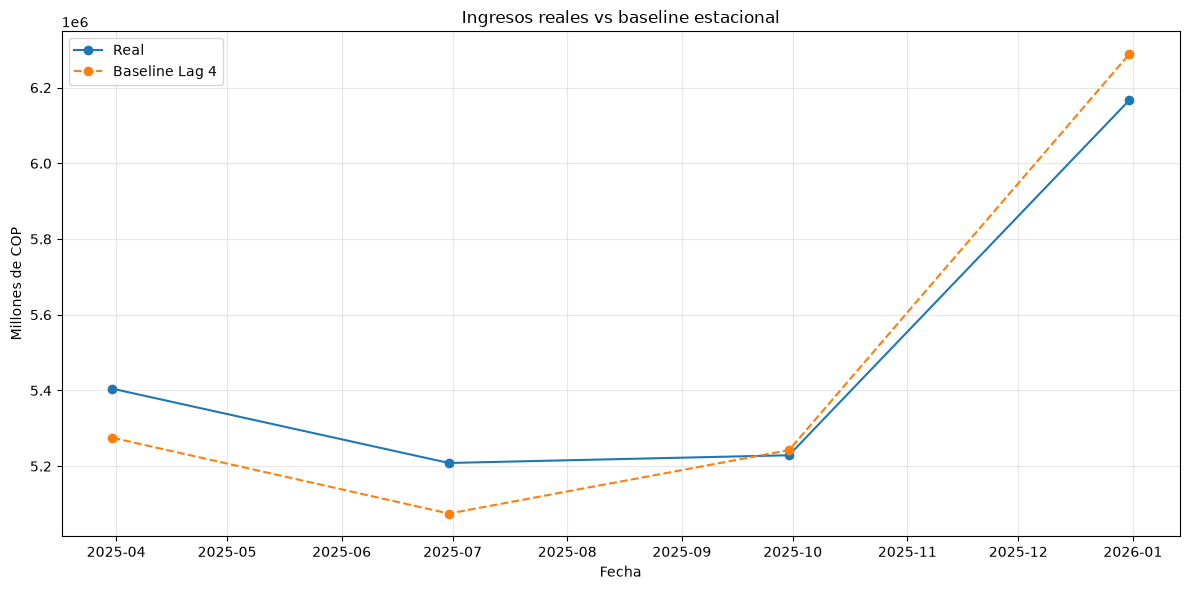

In [16]:
# Comparación real vs baseline ingresos

plt.figure(figsize=(12, 6))

plt.plot(
    df_test["fecha"],
    df_test["ingresos"],
    marker="o",
    label="Real"
)

plt.plot(
    df_test["fecha"],
    df_test["ingresos_baseline"],
    marker="o",
    linestyle="--",
    label="Baseline Lag 4"
)

plt.title(
    "Ingresos reales vs baseline estacional"
)

plt.xlabel("Fecha")
plt.ylabel("Millones de COP")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

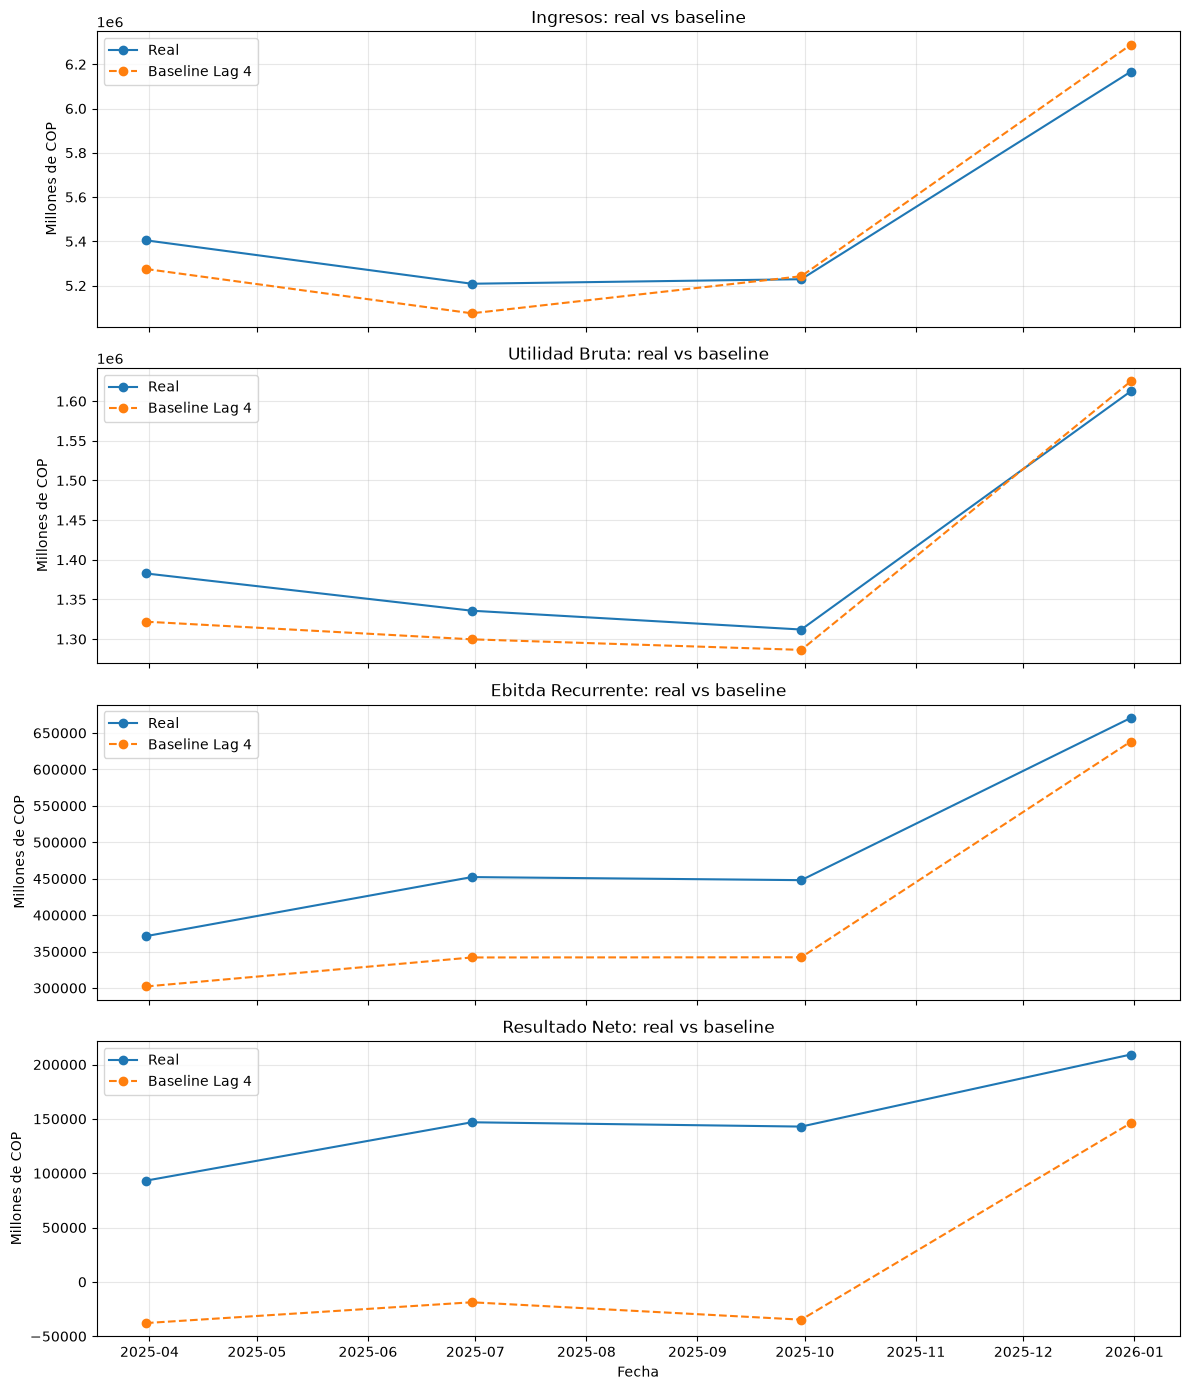

In [17]:
# Comparación de las 4 variables

fig, ax_list = plt.subplots(
    4, 1,
    figsize=(12, 14),
    sharex=True
)

for ax, variable in zip(
    ax_list,
    variables_objetivo
):

    ax.plot(
        df_test["fecha"],
        df_test[variable],
        marker="o",
        label="Real"
    )

    ax.plot(
        df_test["fecha"],
        df_test[f"{variable}_baseline"],
        marker="o",
        linestyle="--",
        label="Baseline Lag 4"
    )

    ax.set_title(
        f"{variable.replace('_', ' ').title()}: real vs baseline"
    )

    ax.set_ylabel("Millones de COP")
    ax.grid(True, alpha=0.3)
    ax.legend()

ax_list[-1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

### Conclusiones del modelo baseline estacional

Se evaluó un modelo baseline estacional que utiliza el valor observado en el mismo trimestre del año anterior para pronosticar cada variable financiera.

Los resultados muestran un desempeño de referencia favorable para los ingresos y la utilidad bruta, con errores porcentuales medios absolutos (MAPE) de 1,80 % y 2,46 %, respectivamente. En contraste, el EBITDA recurrente presenta un MAPE de 17,86 %, lo que evidencia una mayor dificultad para reproducir su comportamiento mediante una referencia estacional simple.

Para el resultado neto se analizaron el MAE y el RMSE, sin utilizar el MAPE debido a las limitaciones de esta métrica cuando existen valores negativos o cercanos a cero.

Estos resultados constituyen la línea base para comparar modelos más avanzados. No implican que el baseline sea el mejor modelo posible; su utilidad se determinará comparando sus errores con los obtenidos mediante otros enfoques de pronóstico.
